In [1]:
import numpy as np
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
from pygam import LinearGAM
import pandas as pd

In [2]:
#Set the default figure size for the notebook, so they are not all tiny
matplotlib.rcParams['figure.figsize'] = (12,8)

Grab a data example from ISL.  Wages for males in the central east coast of the US.  Just a demo.

In [4]:
wage = pd.read_csv('wage.csv', index_col=0)
X = wage[['year', 'age', 'education']].values
X[:,-1] = np.unique(X[:,-1], return_inverse=True)[1]
y = wage['wage']

In [5]:
X

array([[2006, 18, 0],
       [2004, 24, 3],
       [2003, 45, 2],
       ...,
       [2005, 27, 0],
       [2005, 27, 2],
       [2009, 55, 1]], dtype=object)

In [6]:
#Let's make a train-test split for fun
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

In [7]:
fit = LinearGAM().gridsearch(X_train, y_train, lam = np.logspace(-2, 3, 30))
#gam = LinearGAM(n_splines=10).gridsearch(X, y)

100% (30 of 30) |########################| Elapsed Time: 0:00:01 Time:  0:00:01


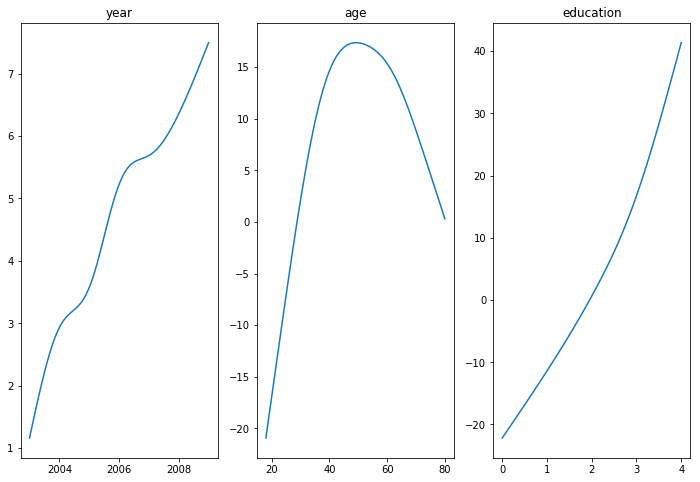

In [20]:
fig, axs = plt.subplots(1, 3)
titles = ['year', 'age', 'education']

for i, ax in enumerate(axs):
    Xfake = fit.generate_X_grid(i)
    pdep, confi = fit.partial_dependence(term = i, X= Xfake, width=.95)

    ax.plot(Xfake[:, i], pdep)
    #ax.plot(XX[:, i], confi[0], c='r', ls='--')
    ax.set_title(titles[i])

plt.show()

In [21]:
from sklearn.metrics import mean_squared_error
yhat = fit.predict(X_test)
mean_squared_error(y_test, yhat)


1200.5113249614242

In [22]:
#Compare to a linear model, does the additive model gain anything?
from sklearn.linear_model import LinearRegression
lmfit = LinearRegression().fit(X_train, y_train)

yhat_lm = lmfit.predict(X_test)
mean_squared_error(y_test, yhat_lm)


1268.0785845812693

# How about in R?

In [23]:
import rpy2
%load_ext rpy2.ipython

In [25]:
%%R 
data(Wage, package='ISLR')

In [28]:
%%R 
head(Wage)

       year age           maritl     race       education             region
231655 2006  18 1. Never Married 1. White    1. < HS Grad 2. Middle Atlantic
86582  2004  24 1. Never Married 1. White 4. College Grad 2. Middle Atlantic
161300 2003  45       2. Married 1. White 3. Some College 2. Middle Atlantic
155159 2003  43       2. Married 3. Asian 4. College Grad 2. Middle Atlantic
11443  2005  50      4. Divorced 1. White      2. HS Grad 2. Middle Atlantic
376662 2008  54       2. Married 1. White 4. College Grad 2. Middle Atlantic
             jobclass         health health_ins  logwage      wage
231655  1. Industrial      1. <=Good      2. No 4.318063  75.04315
86582  2. Information 2. >=Very Good      2. No 4.255273  70.47602
161300  1. Industrial      1. <=Good     1. Yes 4.875061 130.98218
155159 2. Information 2. >=Very Good     1. Yes 5.041393 154.68529
11443  2. Information      1. <=Good     1. Yes 4.318063  75.04315
376662 2. Information 2. >=Very Good     1. Yes 4.845098 12

In [31]:
%%R
library(mgcv)

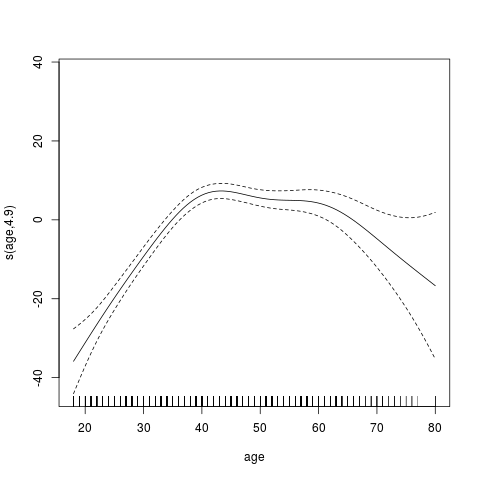

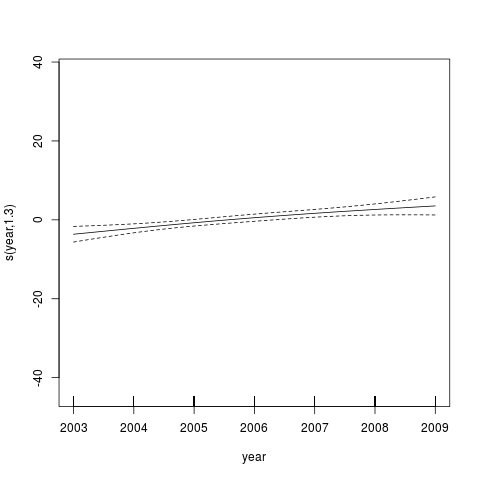

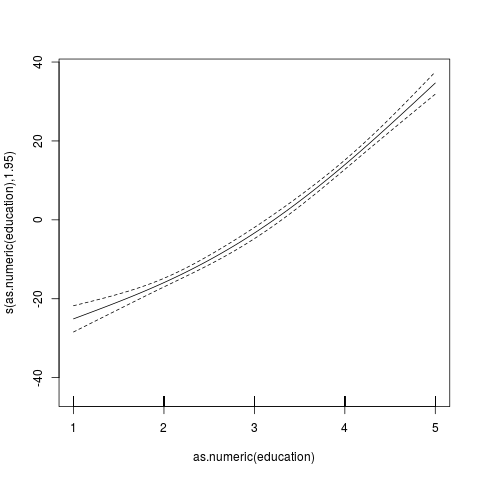

In [38]:
%%R
#We need to constrain things a bit because there are so few unique numbers
#in year and education...
fit = gam(wage ~ s(age) + s(year,k=2) + s(as.numeric(education),k=3), data=Wage)
plot(fit)

In [41]:
%%R
#Make predictions on train set, since we didn't bother splitting for the R version
head(predict(fit, newdata=Wage))

   231655     86582    161300    155159     11443    376662 
 51.29082 101.53212 111.82464 129.35428 100.60535 133.30222 
